# Model SARIMA - Anàlisi de sèries temporals (Sèrie 3)

Aquest notebook analitza la sèrie temporal de casos de pneumònia en població de 15 anys o més a la regió BCN Nord, a partir de dades setmanals del període 2012–2024; utilitzant la metodologia Box-Jenkins.

## Metodologia

1. Anàlisi exploratòria
2. Anàlisi d’estacionarietat
3. Identificació del model
4. Estimació del model
5. Validació
6. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore")


COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Filtratge de dades

Es selecciona el subconjunt corresponent a:

- Diagnòstic: Pneumonia
- Regió: Barcelona Metropolitana Nord
- Grup d'edat: 15+

In [2]:
df_serie = df[
    (df["diagnostic"] == "PneumÃ²nia") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

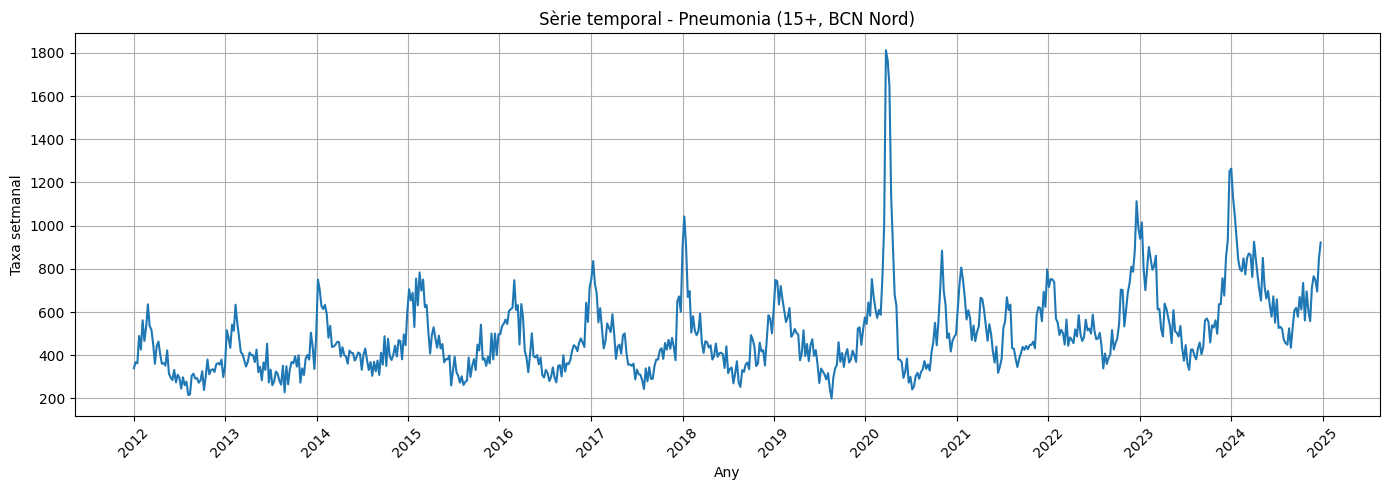

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Pneumonia (15+, BCN Nord)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Divisió Train-Test

El conjunt de dades es divideix en:

- Conjunt d’entrenament: utilitzat per a l’estimació del model (2012–2019)  
- Conjunt test: utilitzat per a la validació i l’avaluació del rendiment predictiu (2020–2024)

In [4]:
serie_3 = serie.copy()

train = serie_3[serie_3.index < "2020-01-01"]
test  = serie_3[serie_3.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


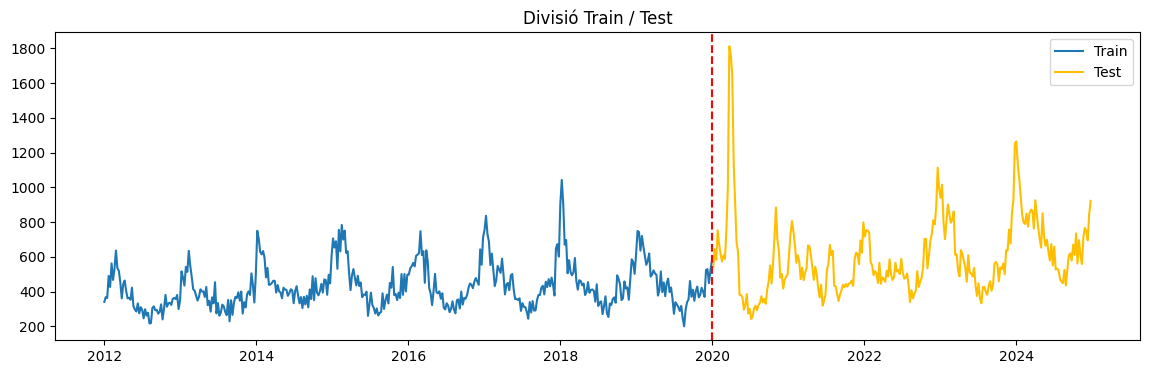

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.show()

## Anàlisi exploratòria

La sèrie temporal original mostra:

- un patró estacional clar,
- canvis en la variabilitat al llarg del temps,
- i una possible component de tendència suau.

Com que la variabilitat sembla augmentar amb el nivell de la sèrie, es considera una transformació estabilitzadora de la variància abans de la modelització.

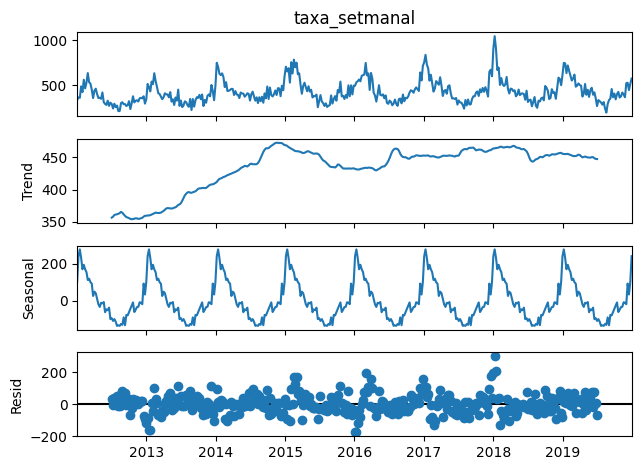

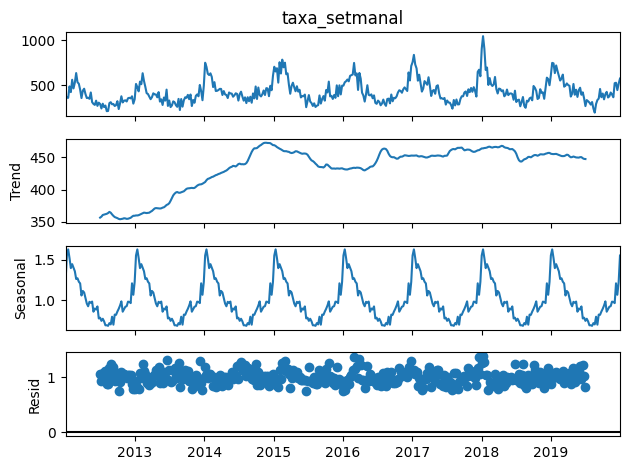

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

decomp_mult = seasonal_decompose(train, model="multiplicative", period=52)
decomp_mult.plot()
plt.show()

Mitjana global (train): 429.12393552200444
Variància global (train): 15736.346409409314

Mitjana per any:
date
2012-12-31    356.493275
2013-12-31    380.345383
2014-12-31    440.240085
2015-12-31    452.511393
2016-12-31    446.004588
2017-12-31    450.860032
2018-12-31    460.780088
2019-12-31    446.544613
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31     8141.644983
2013-12-31     7281.025019
2014-12-31     9465.983945
2015-12-31    19708.249724
2016-12-31    14856.033179
2017-12-31    17807.082087
2018-12-31    24364.637055
2019-12-31    15690.858019
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


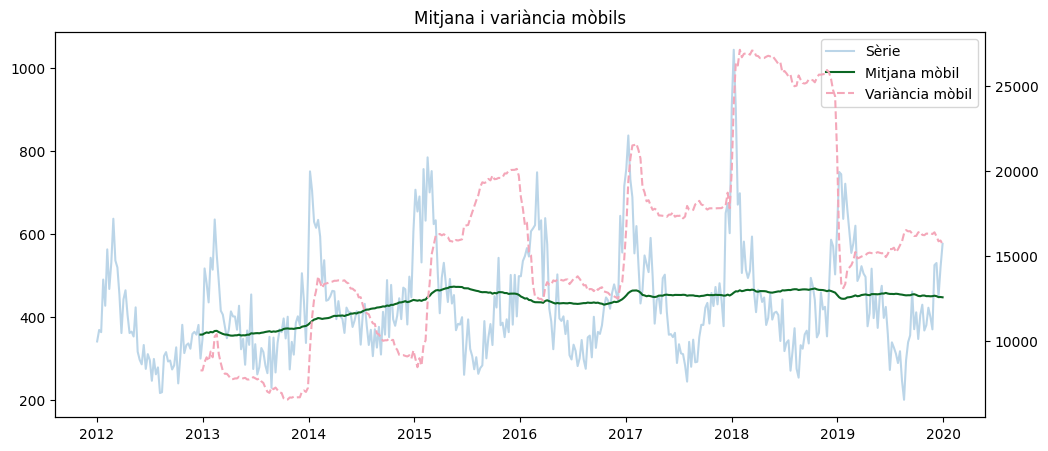

In [7]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbils")
plt.show()

## Transformació logarítmica

Com que la variància no és estable en l’escala original, s’aplica una transformació logarítmica.

Després de la transformació, la sèrie mostra una variabilitat més homogènia al llarg del temps. Per tant, l’anàlisi i la posterior modelització SARIMA es duen a terme sobre la sèrie transformada en escala logarítmica.

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


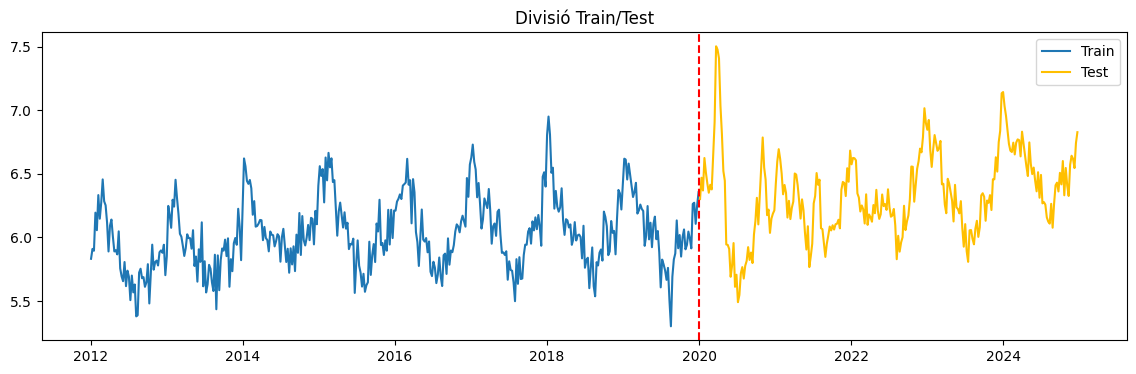

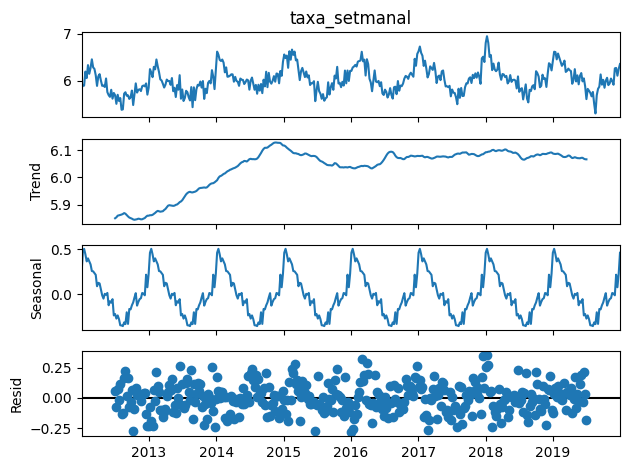

Mitjana global (train_log): 6.025698138775522
variància global (train_log): 0.07445753390920708

Mitjana per any:
date
2012-12-31    5.850479
2013-12-31    5.919982
2014-12-31    6.068587
2015-12-31    6.072791
2016-12-31    6.067451
2017-12-31    6.073352
2018-12-31    6.089585
2019-12-31    6.065499
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    0.056472
2013-12-31    0.047995
2014-12-31    0.040504
2015-12-31    0.088282
2016-12-31    0.070663
2017-12-31    0.079923
2018-12-31    0.085568
2019-12-31    0.079221
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


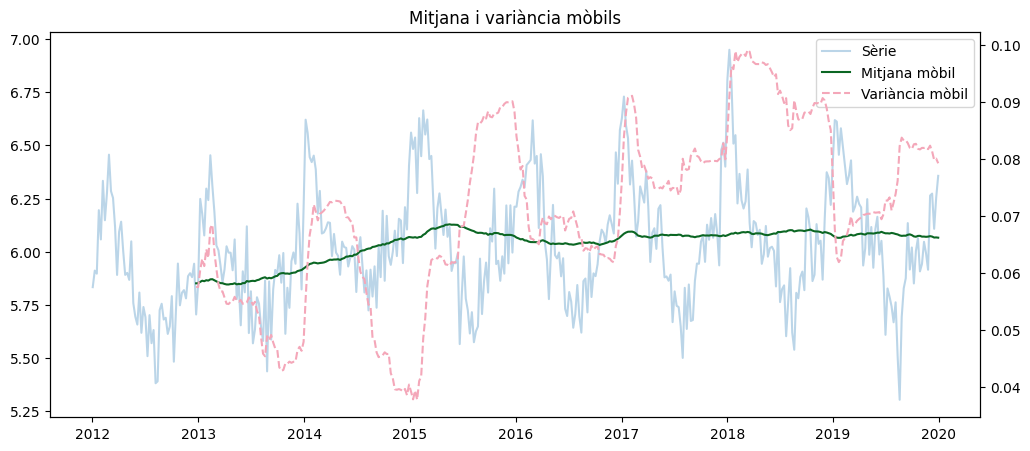

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train/Test")
plt.show()

decomp_log = seasonal_decompose(train_log, model="additive", period=52)
decomp_log.plot()
plt.show()

print("Mitjana global (train_log):", train_log.mean())
print("variància global (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_meanlog, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbils")
plt.show()

## ACF original

Després de la descomposició, s’examina l’ACF de la sèrie original per avaluar la possible presència d’estacionalitat.

Els pics significatius en retards estacionals, especialment al voltant de m = 52, suggereixen un patró estacional anual clar. Això proporciona una primera indicació que podria ser necessària una diferenciació estacional.

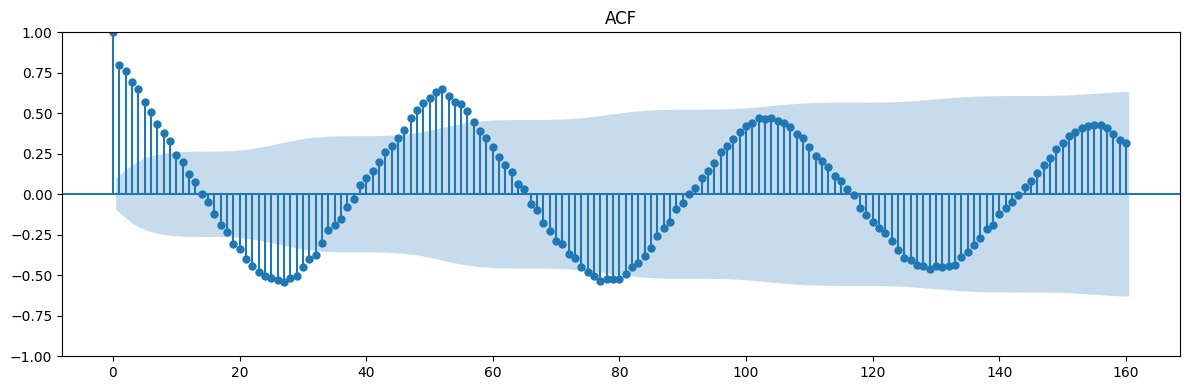

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

## Anàlisi d’estacionarietat

S’apliquen les proves estadístiques següents:
- Test Augmented Dickey-Fuller (ADF)
- Test KPSS

## Interpretació
- ADF: H0 = no estacionària
- KPSS: H0 = estacionària

Resultats sobre la sèrie transformada logarítmicament:

- Test ADF: es rebutja la hipòtesi nul·la de no estacionarietat
- Test KPSS: no es rebutja la hipòtesi nul·la d’estacionarietat

Els dos tests indiquen que la sèrie transformada és estacionària.

In [10]:
dftest = adfuller(train_log, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Valor : ", dftest[1])

stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-Valor:", p_value)

1. ADF :  -6.156348078417716
P-Valor :  7.352719898308831e-08

2. KPSS : 0.24986934478183243
P-Valor: 0.1


## Anàlisi descriptiva

Per complementar els tests estadístics, es van examinar la mitjana mòbil i la variància mòbil sobre la sèrie transformada en escala logarítmica.
La mitjana mòbil sembla raonablement estable al llarg del temps, mentre que la variància mòbil és notablement més homogènia després de la transformació logarítmica.

Això reforça la idea que la transformació logarítmica millora l’estabilitat de la sèrie i la fa més adequada per a la modelització.

## Comprovació de la diferenciació estacional

Per avaluar més a fons si la diferenciació estacional és adequada, es compara la sèrie després d’aplicar una diferenciació estacional amb la sèrie original, i s’examina novament l’ACF.

Després d’aplicar la diferenciació estacional, el patró anual repetitiu queda substancialment atenuat, i els pics estacionals de l’ACF esdevenen notablement més febles. Això suporta l’elecció d’una diferenciació estacional d’ordre 1 (D = 1).

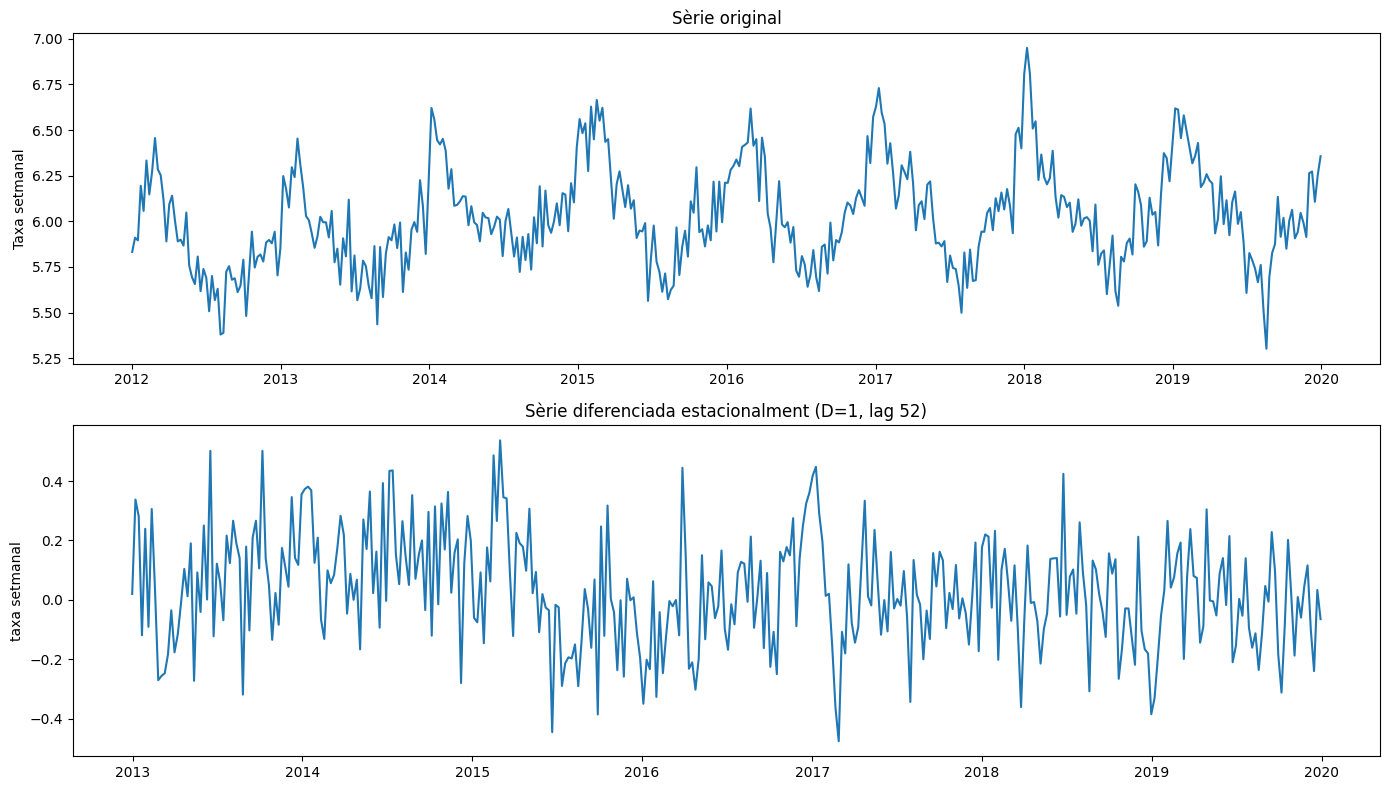

In [11]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Sèrie original")
axes[0].set_ylabel("Taxa setmanal")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1, lag 52)")
axes[1].set_ylabel("taxa setmanal")

plt.tight_layout()
plt.show()

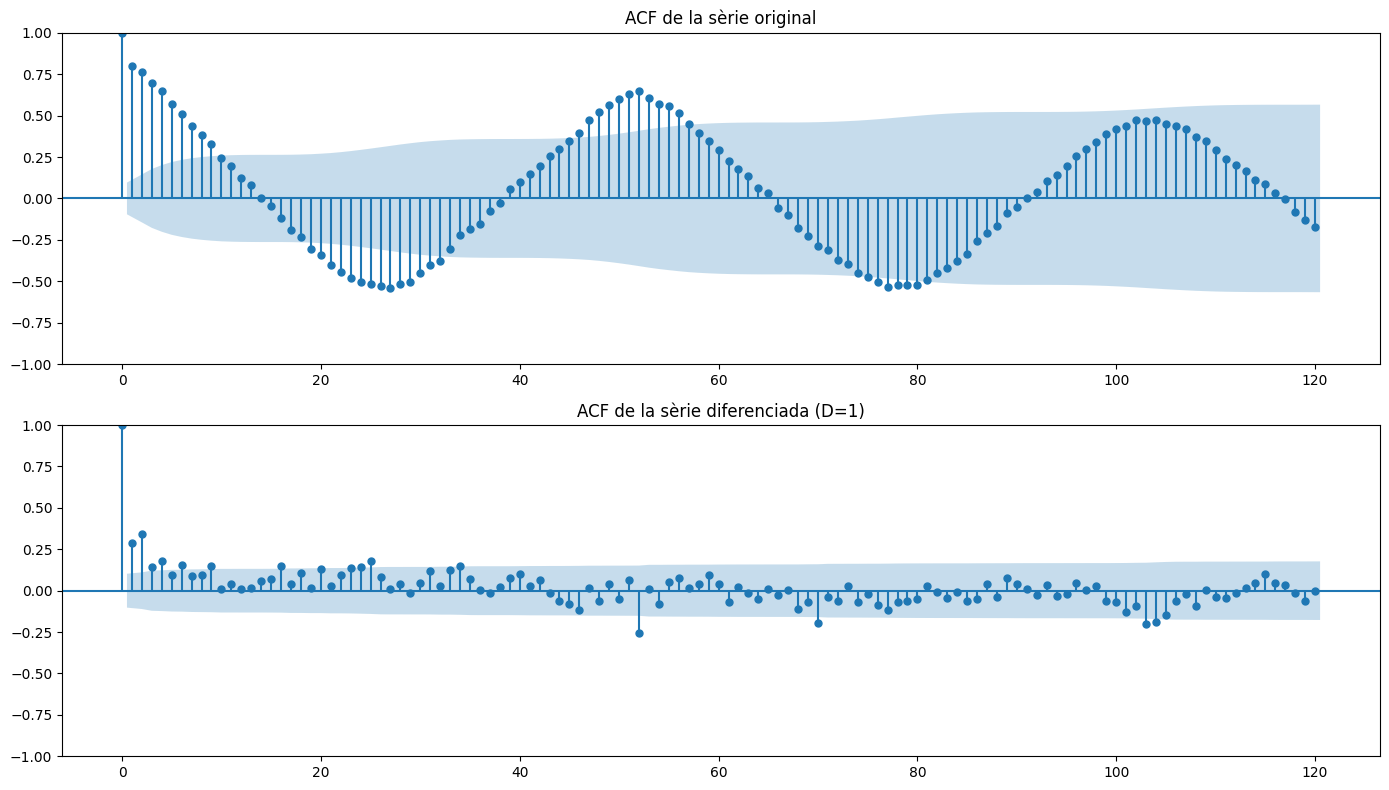

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie original")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada (D=1)")

plt.tight_layout()
plt.show()

## Selecció de la diferenciació

Es manté la transformació logarítmica perquè millora l’estabilitat de la variància, mentre que la mitjana mòbil es manté raonablement estable al llarg del temps.

Pel que fa a l’estructura de la mitjana, els tests formals d’estacionarietat són coherents: el test ADF rebutja la hipòtesi nul·la de no estacionarietat, i el test KPSS no rebutja la hipòtesi nul·la d’estacionarietat. Per tant, no es considera necessària cap diferenciació regular addicional.

Per avaluar l’estacionalitat, es compara la sèrie després d’una diferenciació estacional amb la sèrie original i s’examina de nou l’ACF. Després d’aplicar la diferenciació estacional, el patró anual repetitiu queda substancialment atenuat i els pics estacionals de l’ACF esdevenen notablement més febles. Això dona suport a l’elecció d’una diferenciació estacional d’ordre 1.

Per tant, l’especificació final adopta:

- Diferenciació no estacional: d = 0
- Diferenciació estacional: D = 1

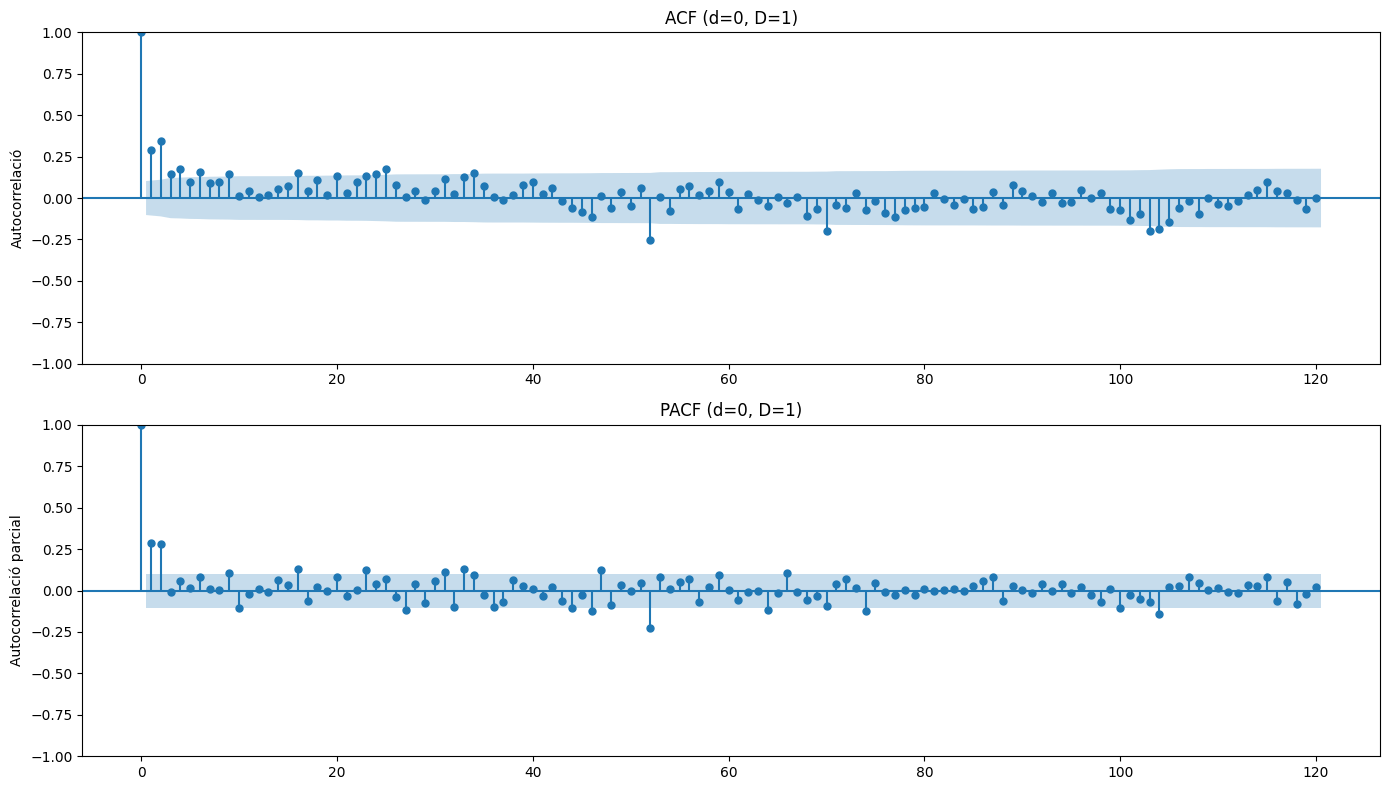

In [13]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

## Anàlisi de l’ACF i la PACF

S’examinen l’ACF i la PACF de la sèrie transformada per orientar l’especificació del model:

- L’ACF mostra un decreixement gradual amb un pic estacional clar al retard 52.
- La PACF suggereix una estructura autoregressiva a curt termini.

Aquest comportament dona suport a la inclusió de components AR i MA, així com d’un terme MA estacional.

## Selecció del model

Es proven diversos models SARIMA a partir de la informació proporcionada per l’ACF i la PACF, i es comparen mitjançant el criteri AIC.

Cada model s’ajusta utilitzant les dades d’entrenament.

In [14]:
models = [
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,1), (0,1,0,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA {order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA {order}{seasonal_order}")


print("\n Millor model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA (1, 0, 1)(0, 1, 1, 52)
AIC: -311.25460568727954
----------------------------------------
Model SARIMA (1, 0, 0)(0, 1, 1, 52)
AIC: -280.01200501212685
----------------------------------------
Model SARIMA (2, 0, 0)(0, 1, 1, 52)
AIC: -301.6787289311345
----------------------------------------
Model SARIMA (2, 0, 1)(0, 1, 1, 52)
AIC: -311.034511469477
----------------------------------------
Model SARIMA (1, 0, 0)(1, 1, 1, 52)
AIC: -258.21102239770164
----------------------------------------
Model SARIMA (1, 0, 1)(0, 1, 0, 52)
AIC: -238.7209455968917
----------------------------------------

 Millor model:
((1, 0, 1), (0, 1, 1, 52))
AIC: -311.25460568727954


In [15]:
model1 = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 159.627
Date:                            Sat, 25 Apr 2026   AIC                           -311.255
Time:                                    18:14:17   BIC                           -296.283
Sample:                                01-02-2012   HQIC                          -305.271
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8747      0.038     23.293      0.000       0.801       0.948
ma.L1         -0.5897      0.071   

In [16]:
model2 = SARIMAX(train_log,
                order=(2,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2= model2.fit()
print(result2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 160.517
Date:                            Sat, 25 Apr 2026   AIC                           -311.035
Time:                                    18:14:36   BIC                           -292.319
Sample:                                01-02-2012   HQIC                          -303.555
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2690      0.067     19.000      0.000       1.138       1.400
ar.L2         -0.2805      0.063   

## Selecció del model per a la validació dels residus

Després d’aquesta primera comparació, només es retenen dos models per a una anàlisi més detallada, ja que ofereixen el millor equilibri entre:

- valors baixos d’AIC,
- paràmetres significatius,
- i una estimació estable.

Aquests dos models se seleccionen com els candidats més sòlids per als diagnòstics dels residus i l’avaluació predictiva.

Per fer aquesta anàlisi més rigorosa, els diagnòstics es calculen excloent el període inicial de burn-in, ja que els primers residus poden estar afectats per la inicialització del filtre en l’estimació SARIMA.

Burn-in utilitzats: 106


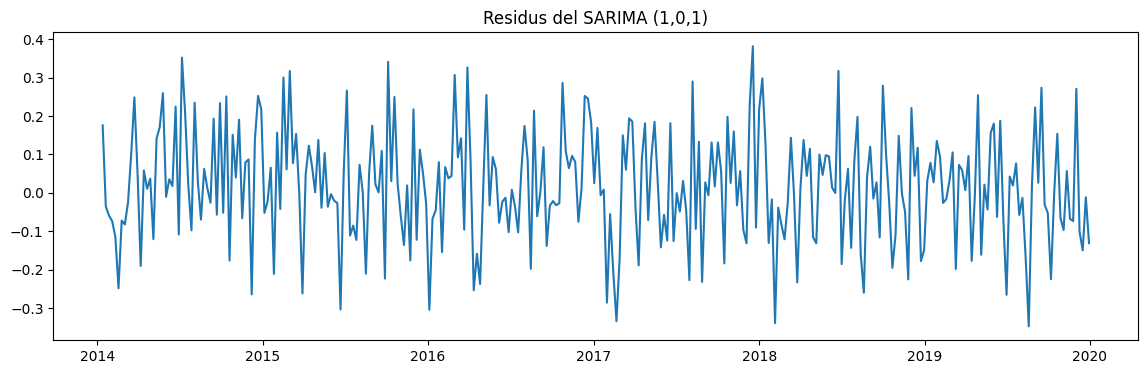

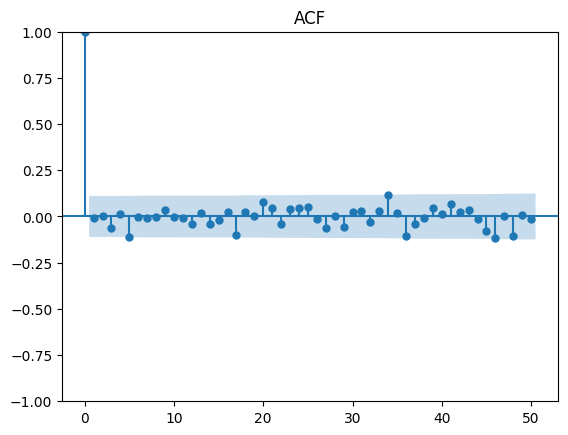


 Ljung Box
      lb_stat  lb_pvalue
10   5.779721   0.833418
20  13.005457   0.877150
30  19.222250   0.935232

Mitjana dels residus: 0.017299318632341267
Desviació estàndard dels residus: 0.14429543667968955
Mitjana relativa (|mitjana| / desviació estàndard): 0.11988818933160518


In [17]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzats: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residus del SARIMA (1,0,1)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 106


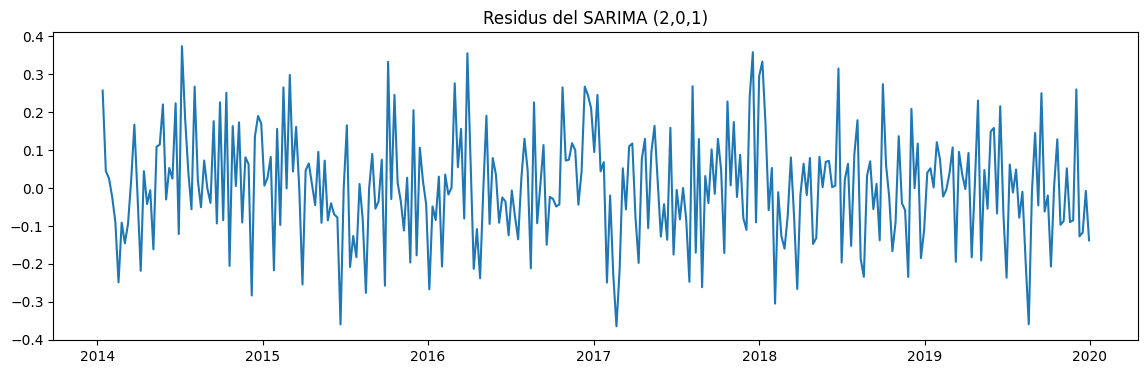

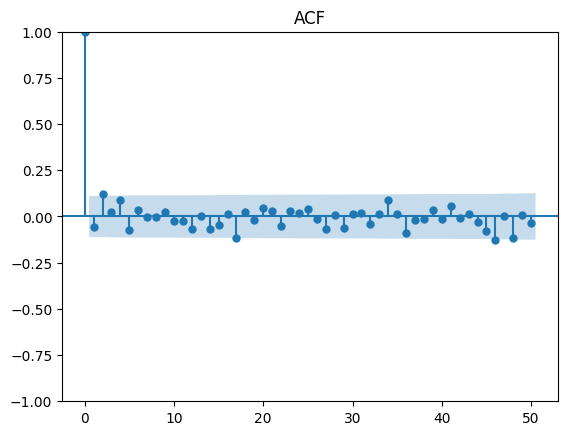


Ljung-Box
      lb_stat  lb_pvalue
10  11.062562   0.352665
20  20.563954   0.423185
30  25.667035   0.692012

Mitjana dels residus: 0.003274951791014711
Desviació estàndard dels residus: 0.1448763752394512
Mitjana relativa (|mitjana| / desviació estàndard): 0.022605147220186046


In [18]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residus del SARIMA (2,0,1)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

## Resultats de la validació dels residus

S’analitzen els residus per avaluar l’adequació del model.

En els dos models candidats, els residus es mantenen centrats al voltant de zero i el seu comportament general és compatible amb un procés aproximadament de soroll blanc. L’autocorrelació residual és, en general, baixa, i els diagnòstics no mostren problemes importants d’especificació.

Tot i que tots dos models presenten diagnòstics residuals acceptables, el SARIMA(1,0,1)(0,1,1,52) mostra resultats lleugerament més favorables en conjunt, especialment pel que fa als estadístics de Ljung–Box i a l’estructura general dels residus. Per tant, des del punt de vista de la validació residual, proporciona una especificació una mica més neta.

In [19]:
# Model 1
pred1 = result1.get_forecast(steps=len(test_log))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test_log, pred1_mean)
rmse1 = root_mean_squared_error(test_log, pred1_mean)


# Model 2
pred2 = result2.get_forecast(steps=len(test_log))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test_log, pred2_mean)
rmse2 = root_mean_squared_error(test_log, pred2_mean)


print("Model (1,0,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (2,0,1) → MAE:", mae2, "RMSE:", rmse2)

Model (1,0,1) → MAE: 0.31742932219399184 RMSE: 0.39066134524079243
Model (2,0,1) → MAE: 0.31561843801944817 RMSE: 0.38884496490529485


## Selecció final del model

Tots dos models candidats mostren un rendiment predictiu molt similar.

Tot i que el model SARIMA(2,0,1)(0,1,1,52) aconsegueix valors lleugerament més baixos de MAE i RMSE, la millora és només marginal. En canvi, el model SARIMA(1,0,1)(0,1,1,52) combina un AIC més baix, uns diagnòstics residuals lleugerament més favorables i una estructura més parsimoniosa.

Per tant, se selecciona el model SARIMA(1,0,1)(0,1,1,52) com a model final, ja que proporciona el millor equilibri global entre bondat d’ajust, comportament dels residus, rendiment predictiu i simplicitat del model.

## Predicció

Un cop s’ha validat el model, es generen prediccions utilitzant l’horitzó del conjunt de prova. L’objectiu és avaluar fins a quin punt el model capta:

- la tendència global
- el patró estacional
- la variabilitat de la sèrie

Les prediccions s’acompanyen d’intervals de predicció, que reflecteixen la incertesa del model.

In [20]:
model = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log)

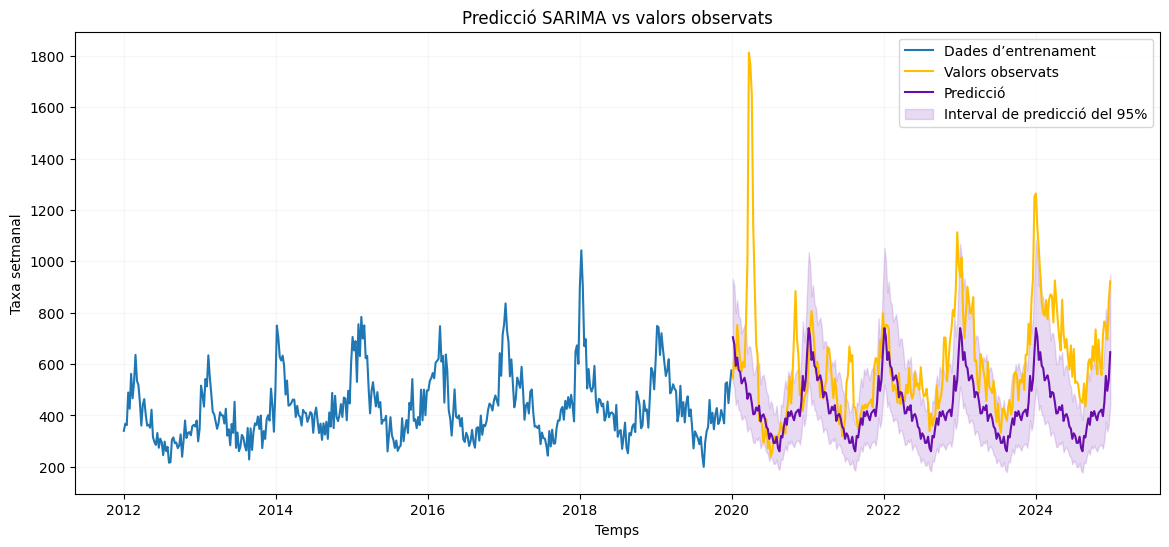

In [21]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.legend()
plt.title("Predicció SARIMA vs valors observats")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()

In [22]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Cobertura:", covTotal)

TOTAL
MAE: 175.30781222006593
RMSE: 247.25255757494898
Cobertura: 0.6038461538461538


## Avaluació de la predicció

Per avaluar quantitativament el rendiment predictiu, es calculen mètriques d’error com:

- Error absolut mitjà (MAE)
- Arrel de l’error quadràtic mitjà (RMSE)

Aquestes mètriques mesuren la diferència entre els valors observats i els valors predits, i permeten valorar la precisió del model.

La cobertura empírica dels intervals de predicció del 95% és d’aproximadament 0'6, per sota del nivell nominal, fet que suggereix que la incertesa de la predicció està infraestimada.

Per analitzar-ho amb més detall, el període de test es divideix en dos subperíodes:

- Període COVID
- Període post-COVID

Això permet estudiar si el model es comporta de manera diferent davant de canvis estructurals en les dades.

In [23]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Cobertura:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)


cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Cobertura:", cov_post)


COVID (2020-2021)
MAE: 147.0794792538757
RMSE: 272.9121960407582
Cobertura: 0.75

POST-COVID (2022-2024)
MAE: 194.12670086419277
RMSE: 228.5512361529969
Cobertura: 0.5064102564102564


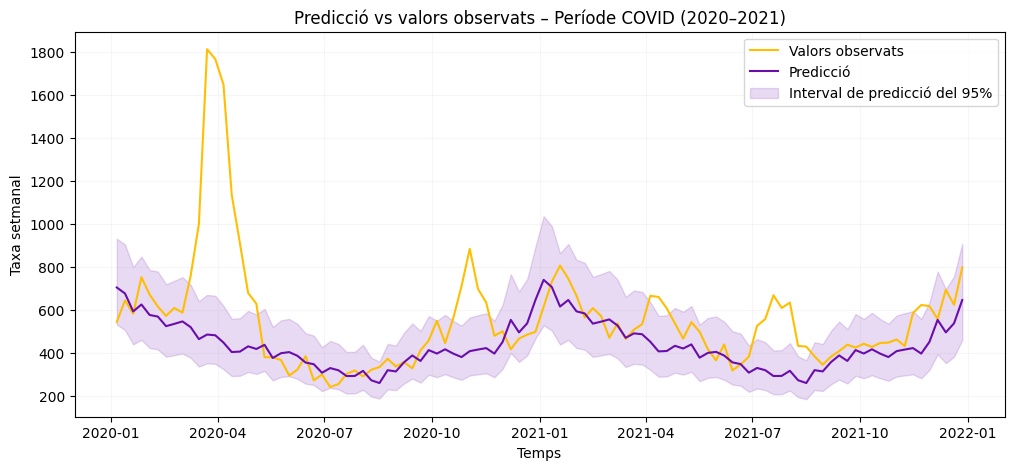

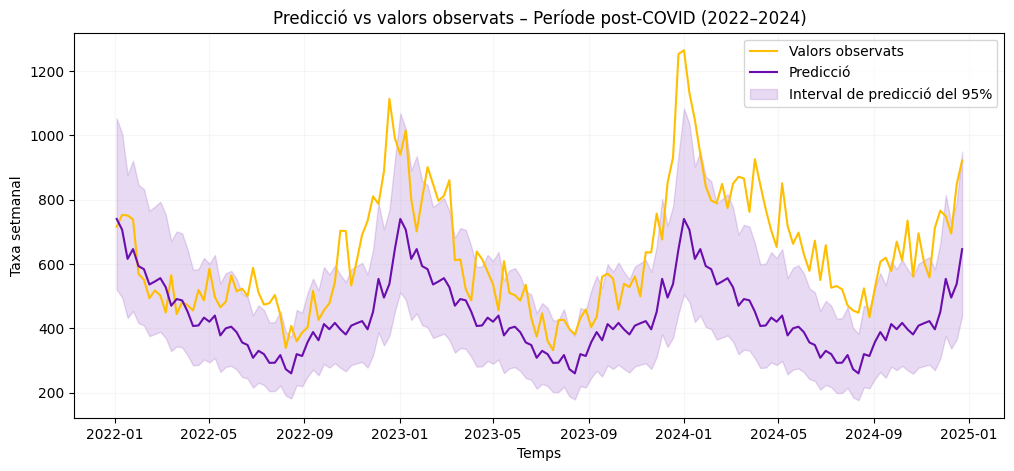

In [24]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

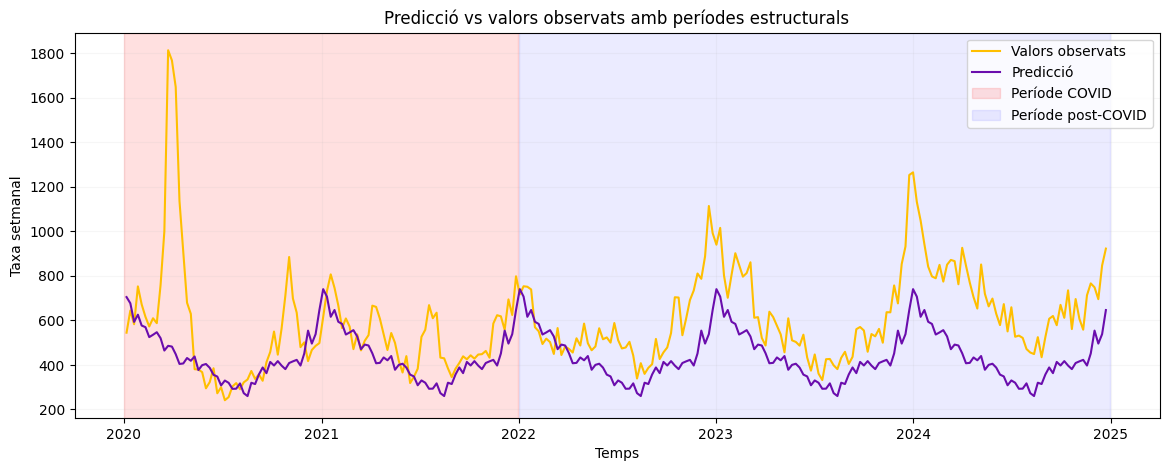

In [25]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='Període COVID')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Període post-COVID')

plt.legend()
plt.title("Predicció vs valors observats amb períodes estructurals")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)

plt.show()

## Anàlisi visual (Pneumònia)

La sèrie de pneumònia presenta un comportament diferent en comparació amb altres diagnòstics, tant visualment com pel que fa a les mètriques de predicció.

Durant el període COVID (2020–2021), el model mostra una cobertura relativament bona (~0'76), és a dir, una gran proporció dels valors observats cau dins dels intervals de confiança predits. Tanmateix, les mètriques d’error, com l’RMSE, són més elevades, fet que indica que, quan el model s’equivoca, ho fa amb desviacions més grans.

Això suggereix que el model captura la incertesa general d’aquest període, però té dificultats per estimar amb precisió la magnitud dels canvis. Una explicació plausible és el canvi en les pràctiques diagnòstiques, en què molts casos respiratoris es van classificar com a COVID-19 en lloc de pneumònia, alterant de manera més sistemàtica el procés generador de les dades.

En canvi, durant el període post-COVID (2022–2024), el model obté un RMSE més baix, fet que indica millors prediccions puntuals. No obstant això, la cobertura disminueix significativament (~0'52), cosa que suggereix que els intervals de predicció no estan ben calibrats i no capturen adequadament la variabilitat real de la sèrie.

Visualment, això és coherent amb un model que segueix més de prop el nivell general de la sèrie, però que infraestima la variabilitat i no captura alguns pics amb prou freqüència.

En conjunt, aquest comportament posa de manifest un compromís entre la precisió puntual i l’estimació de la incertesa, i reforça la idea que el rendiment del model s’ha d’interpretar més enllà d’una única mètrica.